# Five Number Summary

This notebook demonstrates:

- Five Number Summary
- Quartiles
- Median
- Interquartile Range (IQR)
- IQR-based outlier detection
- Box Plot

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = np.array([
    1, 2, 2, 2, 3, 3, 4, 5, 5, 5,
    6, 6, 6, 6, 7, 8, 8, 9, 27
])

data = np.sort(data)

print("Sorted Dataset:")
print(data)

print("\nNumber of observations:", len(data))

Sorted Dataset:
[ 1  2  2  2  3  3  4  5  5  5  6  6  6  6  7  8  8  9 27]

Number of observations: 19


In [3]:
minimum = np.min(data)
Q1 = np.percentile(data, 25)
median = np.percentile(data, 50)
Q3 = np.percentile(data, 75)
maximum = np.max(data)

five_number_summary = pd.DataFrame({
    "Statistic": [
        "Minimum",
        "Q1",
        "Median",
        "Q3",
        "Maximum"
    ],
    "Value": [
        minimum,
        Q1,
        median,
        Q3,
        maximum
    ]
})

five_number_summary

,Statistic,Value
0,Minimum,1.0
1,Q1,3.0
2,Median,5.0
3,Q3,6.5
4,Maximum,27.0


In [5]:
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 3.0
Q3: 6.5
IQR: 3.5


In [6]:
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print("Lower Fence:", lower_fence)
print("Upper Fence:", upper_fence)

Lower Fence: -2.25
Upper Fence: 11.75


In [7]:
outliers = data[
    (data < lower_fence) |
    (data > upper_fence)
]

print("Potential Outliers:")
print(outliers)

Potential Outliers:
[27]


In [8]:
non_outliers = data[
    (data >= lower_fence) &
    (data <= upper_fence)
]

print("Non-Outliers:")
print(non_outliers)

print("\nPotential Outliers:")
print(outliers)

Non-Outliers:
[1 2 2 2 3 3 4 5 5 5 6 6 6 6 7 8 8 9]

Potential Outliers:
[27]


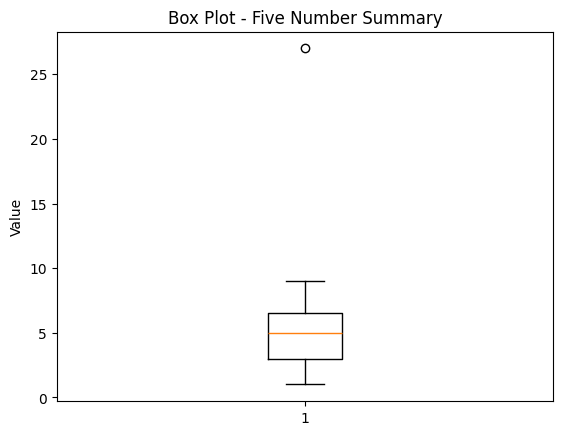

In [9]:
plt.boxplot(data)

plt.ylabel("Value")
plt.title("Box Plot - Five Number Summary")

plt.show()

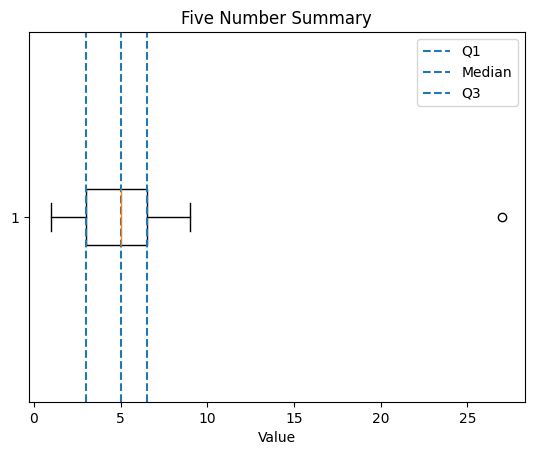

In [10]:
plt.boxplot(
    data,
    vert=False
)

plt.axvline(
    Q1,
    linestyle="--",
    label="Q1"
)

plt.axvline(
    median,
    linestyle="--",
    label="Median"
)

plt.axvline(
    Q3,
    linestyle="--",
    label="Q3"
)

plt.xlabel("Value")
plt.title("Five Number Summary")

plt.legend()
plt.show()

In [11]:
series = pd.Series(data)

print(series.describe())

count    19.000000
mean      6.052632
std       5.562510
min       1.000000
25%       3.000000
50%       5.000000
75%       6.500000
max      27.000000
dtype: float64


## Summary

Five Number Summary:

- Minimum → Smallest observation
- Q1 → 25th percentile
- Median → 50th percentile
- Q3 → 75th percentile
- Maximum → Largest observation

IQR:

IQR = Q3 - Q1

Potential outliers are identified using:

Lower Fence = Q1 - 1.5 × IQR
Upper Fence = Q3 + 1.5 × IQR